In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file into a pandas DataFrame
df = pd.read_csv("Customer_support_data.csv")

# Display the first 5 rows to inspect columns
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [2]:
# 1. Check the total number of rows and columns
print("--- DATASET SHAPE ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 2. Check column names, non-null counts, and data types
print("\n--- DATASET OVERVIEW ---")
df.info()

--- DATASET SHAPE ---
Rows: 85907, Columns: 20

--- DATASET OVERVIEW ---
<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  str    
 1   channel_name             85907 non-null  str    
 2   category                 85907 non-null  str    
 3   Sub-category             85907 non-null  str    
 4   Customer Remarks         28742 non-null  str    
 5   Order_id                 67675 non-null  str    
 6   order_date_time          17214 non-null  str    
 7   Issue_reported at        85907 non-null  str    
 8   issue_responded          85907 non-null  str    
 9   Survey_response_Date     85907 non-null  str    
 10  Customer_City            17079 non-null  str    
 11  Product_category         17196 non-null  str    
 12  Item_price               17206 non-null  float64
 13  connected_hand

In [3]:
# 1. Count missing values in every column
print("--- MISSING VALUES PER COLUMN ---")
missing_count = df.isnull().sum()
print(missing_count[missing_count > 0])

# 2. Calculate percentage of missing values for columns that have nulls
print("\n--- MISSING VALUE PERCENTAGES (%) ---")
missing_percent = (missing_count / len(df)) * 100
print(missing_percent[missing_percent > 0].round(2))

# 3. Check for exact duplicate rows
print("\n--- DUPLICATE ROWS COUNT ---")
print(f"Total Exact Duplicate Rows: {df.duplicated().sum()}")

--- MISSING VALUES PER COLUMN ---
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
dtype: int64

--- MISSING VALUE PERCENTAGES (%) ---
Customer Remarks           66.54
Order_id                   21.22
order_date_time            79.96
Customer_City              80.12
Product_category           79.98
Item_price                 79.97
connected_handling_time    99.72
dtype: float64

--- DUPLICATE ROWS COUNT ---
Total Exact Duplicate Rows: 0


In [7]:
# 1. Count missing values in every column
print("--- MISSING VALUES PER COLUMN ---")
missing_count = df.isnull().sum()
print(missing_count[missing_count > 0])

# 2. Calculate percentage of missing values for columns that have nulls
print("\n--- MISSING VALUE PERCENTAGES (%) ---")
missing_percent = (missing_count / len(df)) * 100
print(missing_percent[missing_percent > 0].round(2))

# 3. Check for exact duplicate rows
print("\n--- DUPLICATE ROWS COUNT ---")
print(f"Total Exact Duplicate Rows: {df.duplicated().sum()}")

--- MISSING VALUES PER COLUMN ---
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
dtype: int64

--- MISSING VALUE PERCENTAGES (%) ---
Customer Remarks           66.54
Order_id                   21.22
order_date_time            79.96
Customer_City              80.12
Product_category           79.98
Item_price                 79.97
connected_handling_time    99.72
dtype: float64

--- DUPLICATE ROWS COUNT ---
Total Exact Duplicate Rows: 0


In [5]:
# 1. Drop rows where CSAT Score is missing (target variable)
df_clean = df.dropna(subset=['CSAT Score']).copy()

# 2. Convert timestamp strings to datetime objects
df_clean['Issue_reported at'] = pd.to_datetime(df_clean['Issue_reported at'], errors='coerce')
df_clean['issue_responded'] = pd.to_datetime(df_clean['issue_responded'], errors='coerce')

# 3. Feature Engineering: Calculate Response Time in Minutes
df_clean['Response_Time_Mins'] = (
    df_clean['issue_responded'] - df_clean['Issue_reported at']
).dt.total_seconds() / 60.0

# 4. Impute missing numerical values with column medians
if 'Item_price' in df_clean.columns:
    df_clean['Item_price'] = df_clean['Item_price'].fillna(df_clean['Item_price'].median())

if 'connected_handling_time' in df_clean.columns:
    df_clean['connected_handling_time'] = df_clean['connected_handling_time'].fillna(
        df_clean['connected_handling_time'].median()
    )

# 5. Check the updated shape
print("--- CLEANING COMPLETE ---")
print(f"Original rows: {len(df)}")
print(f"Cleaned rows with valid CSAT scores: {len(df_clean)}")
print(f"New column created: Response_Time_Mins")

--- CLEANING COMPLETE ---
Original rows: 85907
Cleaned rows with valid CSAT scores: 85907
New column created: Response_Time_Mins


In [8]:
# Select key numerical columns for statistical analysis
num_cols = ['CSAT Score', 'Response_Time_Mins', 'Item_price', 'connected_handling_time']
existing_cols = [col for col in num_cols if col in df_clean.columns]

# Generate detailed summary statistics
print("--- NUMERICAL SUMMARY STATISTICS ---")
print(df_clean[existing_cols].describe().T)

# Detailed breakdown specifically for our Target Variable (CSAT Score)
print("\n--- CSAT SCORE FREQUENCY COUNT ---")
print(df_clean['CSAT Score'].value_counts().sort_index(ascending=False))

print("\n--- CSAT SCORE PERCENTAGES (%) ---")
print((df_clean['CSAT Score'].value_counts(normalize=True).sort_index(ascending=False) * 100).round(2))

--- NUMERICAL SUMMARY STATISTICS ---
                           count         mean           std  min    25%  \
CSAT Score               85907.0     4.242157      1.378903  1.0    4.0   
Response_Time_Mins       31633.0  4647.152214  17113.187472  0.0    2.0   
Item_price               85907.0  1916.695624   6037.903897  0.0  979.0   
connected_handling_time  85907.0   427.099724     13.179491  0.0  427.0   

                           50%    75%       max  
CSAT Score                 5.0    5.0       5.0  
Response_Time_Mins         6.0   41.0  177097.0  
Item_price               979.0  979.0  164999.0  
connected_handling_time  427.0  427.0    1986.0  

--- CSAT SCORE FREQUENCY COUNT ---
CSAT Score
5    59617
4    11219
3     2558
2     1283
1    11230
Name: count, dtype: int64

--- CSAT SCORE PERCENTAGES (%) ---
CSAT Score
5    69.40
4    13.06
3     2.98
2     1.49
1    13.07
Name: proportion, dtype: float64


C:\Users\rakesh\AppData\Local\Temp\ipykernel_13188\2058632875.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='CSAT Score', ax=axes[0], palette='Blues_d')
C:\Users\rakesh\AppData\Local\Temp\ipykernel_13188\2058632875.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_avg, x='channel_name', y='CSAT Score', ax=axes[1], palette='crest')


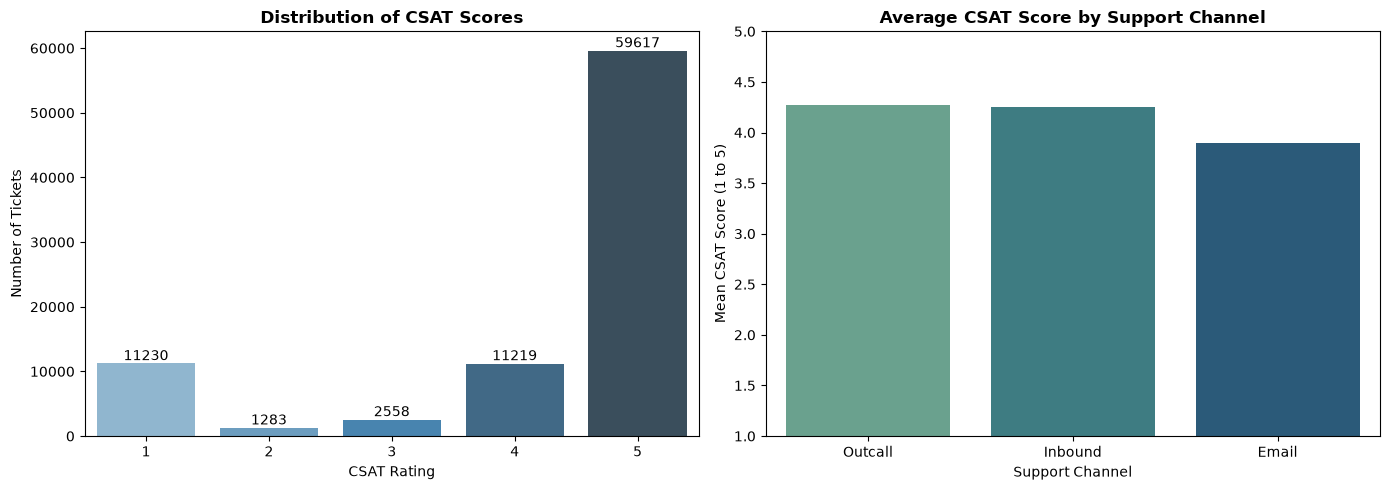

In [9]:
# Create a figure with 1 row and 2 columns for plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Total Count per CSAT Rating (1 to 5)
sns.countplot(data=df_clean, x='CSAT Score', ax=axes[0], palette='Blues_d')
axes[0].set_title('Distribution of CSAT Scores', fontsize=12, fontweight='bold')
axes[0].set_xlabel('CSAT Rating')
axes[0].set_ylabel('Number of Tickets')

# Add exact count numbers on top of each bar
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Plot 2: Average CSAT Score by Support Channel
if 'channel_name' in df_clean.columns:
    channel_avg = df_clean.groupby('channel_name')['CSAT Score'].mean().reset_index()
    channel_avg = channel_avg.sort_values(by='CSAT Score', ascending=False)
    
    sns.barplot(data=channel_avg, x='channel_name', y='CSAT Score', ax=axes[1], palette='crest')
    axes[1].set_title('Average CSAT Score by Support Channel', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Support Channel')
    axes[1].set_ylabel('Mean CSAT Score (1 to 5)')
    axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.show()

C:\Users\rakesh\AppData\Local\Temp\ipykernel_13188\1157638703.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='CSAT Score', y='Response_Time_Mins', ax=axes[1], palette='Set2')


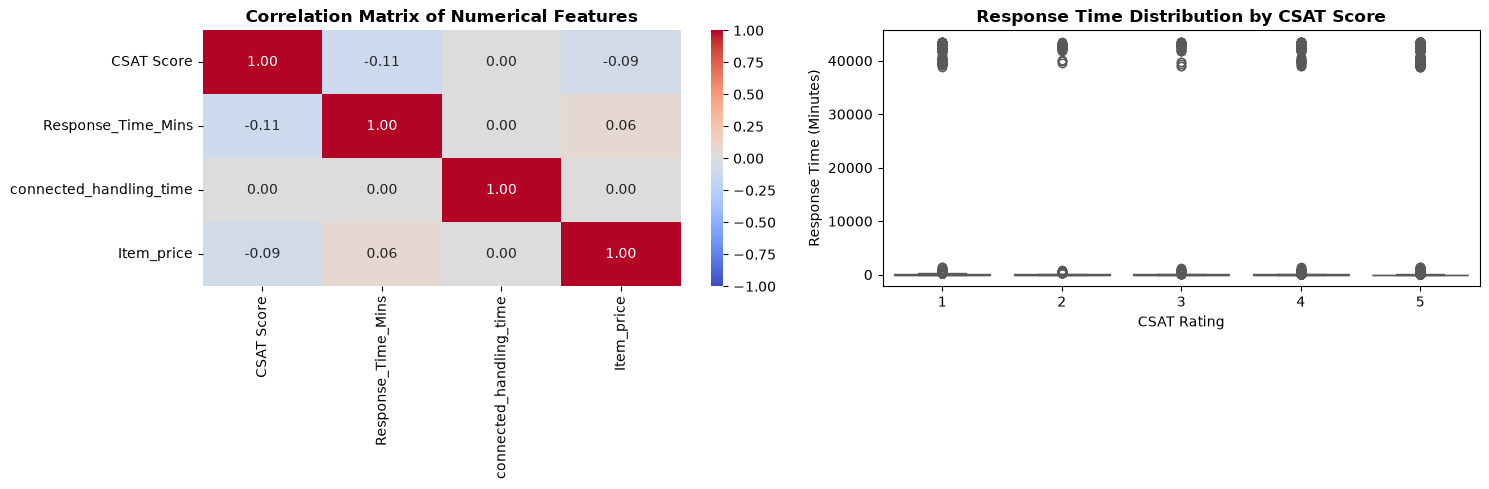

In [10]:
# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Correlation Matrix Heatmap
num_cols = ['CSAT Score', 'Response_Time_Mins', 'connected_handling_time', 'Item_price']
existing_num_cols = [col for col in num_cols if col in df_clean.columns]

corr_matrix = df_clean[existing_num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation Matrix of Numerical Features', fontsize=12, fontweight='bold')

# Plot 2: Boxplot - Response Time (Mins) across CSAT Scores
# Removing extreme outliers (> 95th percentile) for a clearer boxplot view
upper_limit = df_clean['Response_Time_Mins'].quantile(0.95)
df_filtered = df_clean[df_clean['Response_Time_Mins'] <= upper_limit]

sns.boxplot(data=df_filtered, x='CSAT Score', y='Response_Time_Mins', ax=axes[1], palette='Set2')
axes[1].set_title('Response Time Distribution by CSAT Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('CSAT Rating')
axes[1].set_ylabel('Response Time (Minutes)')

plt.tight_layout()
plt.show()

C:\Users\rakesh\AppData\Local\Temp\ipykernel_13188\1157638703.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='CSAT Score', y='Response_Time_Mins', ax=axes[1], palette='Set2')


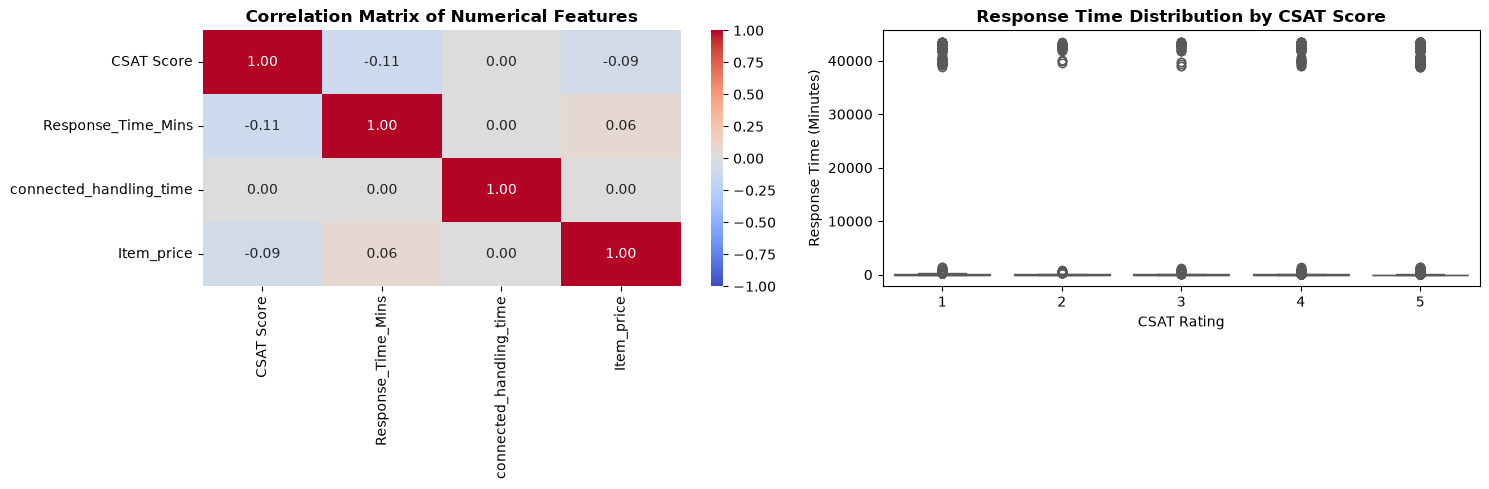

In [11]:
# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Correlation Matrix Heatmap
num_cols = ['CSAT Score', 'Response_Time_Mins', 'connected_handling_time', 'Item_price']
existing_num_cols = [col for col in num_cols if col in df_clean.columns]

corr_matrix = df_clean[existing_num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation Matrix of Numerical Features', fontsize=12, fontweight='bold')

# Plot 2: Boxplot - Response Time (Mins) across CSAT Scores
# Removing extreme outliers (> 95th percentile) for a clearer boxplot view
upper_limit = df_clean['Response_Time_Mins'].quantile(0.95)
df_filtered = df_clean[df_clean['Response_Time_Mins'] <= upper_limit]

sns.boxplot(data=df_filtered, x='CSAT Score', y='Response_Time_Mins', ax=axes[1], palette='Set2')
axes[1].set_title('Response Time Distribution by CSAT Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('CSAT Rating')
axes[1].set_ylabel('Response Time (Minutes)')

plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

# 1. Define Candidate Feature Columns (Numerical + Categorical)
num_features = ['Response_Time_Mins', 'connected_handling_time', 'Item_price']
cat_features = ['channel_name', 'Agent Shift', 'category']

# Filter only existing columns in the cleaned DataFrame
existing_num = [col for col in num_features if col in df_clean.columns]
existing_cat = [col for col in cat_features if col in df_clean.columns]

# Combine selected features and target
all_cols = existing_num + existing_cat + ['CSAT Score']
ml_df = df_clean[all_cols].dropna().copy()

# 2. Separate Features (X) and Target (y)
X_raw = ml_df[existing_num + existing_cat]
y = ml_df['CSAT Score']

# 3. One-Hot Encode Categorical Columns
X = pd.get_dummies(X_raw, columns=existing_cat, drop_first=True)

# 4. Perform Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("--- MACHINE LEARNING PREPROCESSING COMPLETE ---")
print(f"Total Model-Ready Samples: {len(ml_df)}")
print(f"Original Feature Columns: {X_raw.shape[1]}")
print(f"Encoded Feature Columns (X): {X.shape[1]}")
print(f"Training Set Size (X_train): {X_train.shape[0]} rows")
print(f"Testing Set Size (X_test):   {X_test.shape[0]} rows")

--- MACHINE LEARNING PREPROCESSING COMPLETE ---
Total Model-Ready Samples: 31633
Original Feature Columns: 6
Encoded Feature Columns (X): 20
Training Set Size (X_train): 25306 rows
Testing Set Size (X_test):   6327 rows


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Initialize and Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on Test Set
y_pred_lr = lr_model.predict(X_test)

# Calculate Metrics for Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# 2. Initialize and Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on Test Set
y_pred_rf = rf_model.predict(X_test)

# Calculate Metrics for Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# 3. Print Performance Comparison Table
metrics_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R² Score': [r2_lr, r2_rf]
})

print("--- MACHINE LEARNING MODEL PERFORMANCE ---")
print(metrics_df.round(4).to_string(index=False))

--- MACHINE LEARNING MODEL PERFORMANCE ---
                  Model    MAE   RMSE  R² Score
      Linear Regression 1.0604 1.3927    0.0303
Random Forest Regressor 1.0644 1.4654   -0.0735


C:\Users\rakesh\AppData\Local\Temp\ipykernel_13188\1026372583.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')


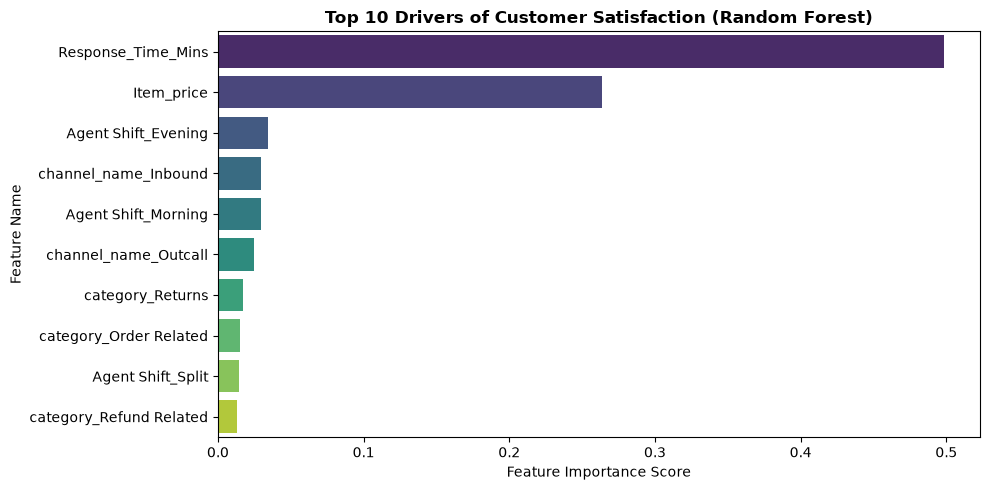

--- TOP 5 MOST INFLUENTIAL FEATURES ---
             Feature  Importance
  Response_Time_Mins      0.4982
          Item_price      0.2638
 Agent Shift_Evening      0.0344
channel_name_Inbound      0.0296
 Agent Shift_Morning      0.0295


In [14]:
# 1. Extract Feature Importances from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Create DataFrame and sort top 10 features
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

# 2. Plot Top 10 Most Important Features
plt.figure(figsize=(10, 5))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Drivers of Customer Satisfaction (Random Forest)', fontsize=12, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

# 3. Print Feature Importance Table
print("--- TOP 5 MOST INFLUENTIAL FEATURES ---")
print(feat_imp_df.head(5).round(4).to_string(index=False))